In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
file_path = 'Seasons_Stats.csv'
df1 = pd.read_csv(file_path)



In [3]:
df1.head()


,Unnamed: 0,Year,Player,Pos,Age,Tm,G,GS,MP,PER,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,0,1950.0,Curly Armstrong,G-F,31.0,FTW,63.0,NaN,NaN,NaN,...,0.705,NaN,NaN,NaN,176.0,NaN,NaN,NaN,217.0,458.0
1,1,1950.0,Cliff Barker,SG,29.0,INO,49.0,NaN,NaN,NaN,...,0.708,NaN,NaN,NaN,109.0,NaN,NaN,NaN,99.0,279.0
2,2,1950.0,Leo Barnhorst,SF,25.0,CHS,67.0,NaN,NaN,NaN,...,0.698,NaN,NaN,NaN,140.0,NaN,NaN,NaN,192.0,438.0
3,3,1950.0,Ed Bartels,F,24.0,TOT,15.0,NaN,NaN,NaN,...,0.559,NaN,NaN,NaN,20.0,NaN,NaN,NaN,29.0,63.0
4,4,1950.0,Ed Bartels,F,24.0,DNN,13.0,NaN,NaN,NaN,...,0.548,NaN,NaN,NaN,20.0,NaN,NaN,NaN,27.0,59.0


In [4]:
df1 = pd.read_csv(file_path);df_clean = df1[['Age','PTS','AST','Pos','Year','MP','WS','3PA']].copy()
df_clean.dropna(inplace=True)
df_clean['Age'] = df_clean['Age'].astype(int)
df_clean['Simple_pos'] = df_clean['Pos'].str[0]
main_positions = ['G', 'F', 'C']
df_multivariate = df_clean[df_clean['Simple_pos'].isin(main_positions)]
df_clean.head()

,Age,PTS,AST,Pos,Year,MP,WS,3PA,Simple_pos
5727,32,2034.0,371.0,C,1980.0,3143.0,14.8,1.0,C
5728,25,362.0,87.0,PF,1980.0,1222.0,2.0,1.0,P
5729,25,1118.0,322.0,C,1980.0,2168.0,7.0,2.0,C
5730,31,1131.0,671.0,PG,1980.0,2864.0,8.9,18.0,P
5731,31,86.0,40.0,C,1980.0,560.0,0.6,0.0,C


Text(0, 0.5, 'PTS')

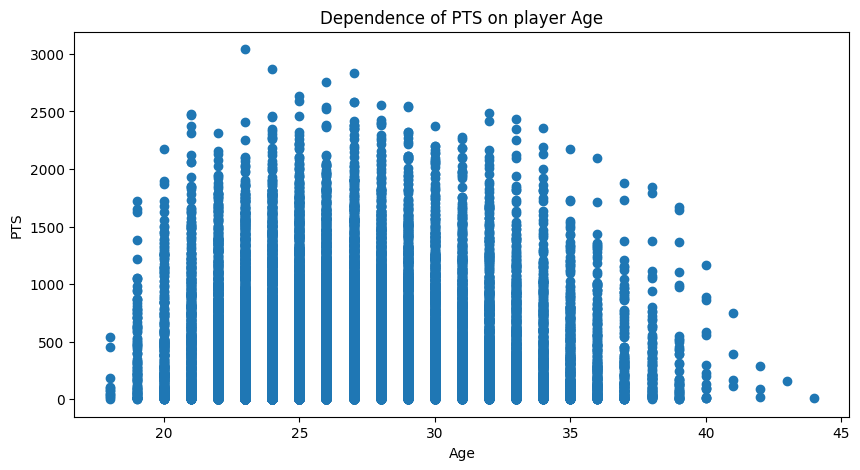

In [5]:
plt.figure(figsize = (10, 5))
plt.scatter(df_clean['Age'], df_clean['PTS'])
plt.title("Dependence of PTS on player Age")
plt.xlabel("Age")
plt.ylabel("PTS")



<Axes: xlabel='Age_group'>

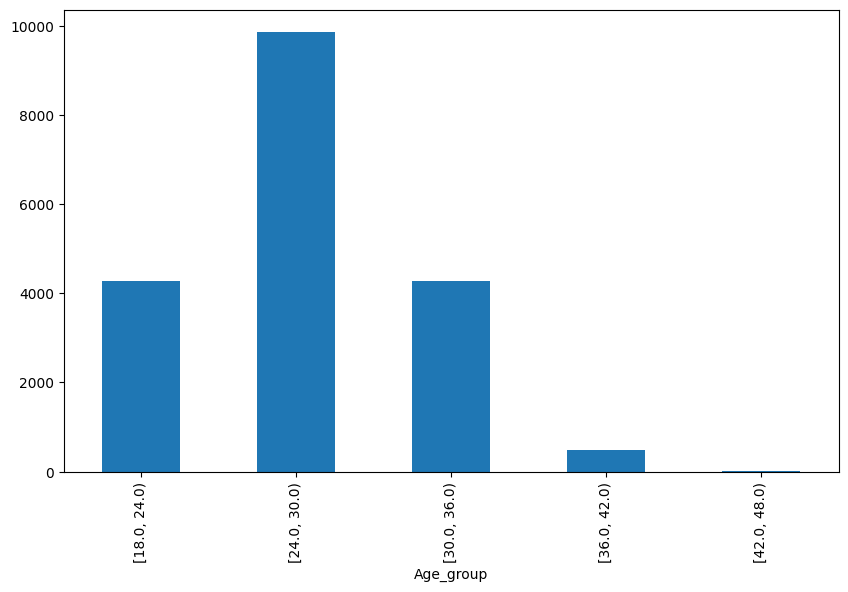

In [6]:
min_age = df_clean["Age"].min()
max_age = df_clean["Age"].max()
num_bins = 5
bin_width = np.ceil((max_age - min_age)/ num_bins)
bins = np.arange(min_age, max_age + bin_width + 1, bin_width)
df_clean["Age_group"] = pd.cut(df_clean['Age'], bins=bins, right=False, include_lowest=True)
age_count = df_clean["Age_group"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
age_count.plot(kind="bar")



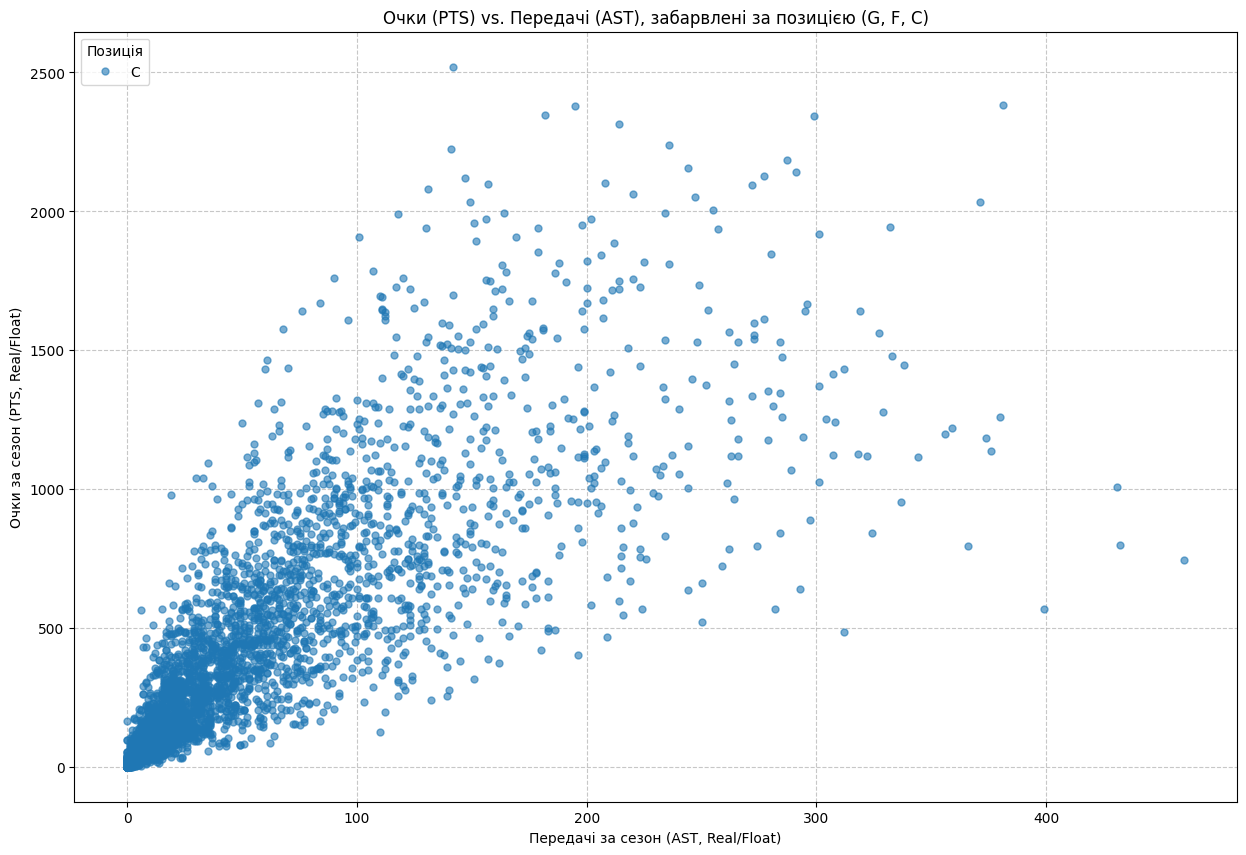

In [7]:
plt.figure(figsize=(15, 10))
groups = df_multivariate.groupby("Simple_pos")
for name,group in groups:
    plt.plot(group["AST"],group["PTS"],marker='o',linestyle='',ms=5,label=name, alpha=0.6)
plt.title('Очки (PTS) vs. Передачі (AST), забарвлені за позицією (G, F, C)')
plt.xlabel('Передачі за сезон (AST, Real/Float)')
plt.ylabel('Очки за сезон (PTS, Real/Float)')
plt.legend(title='Позиція', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

Text(0, 0.5, 'Показник Win Shares (WS)')

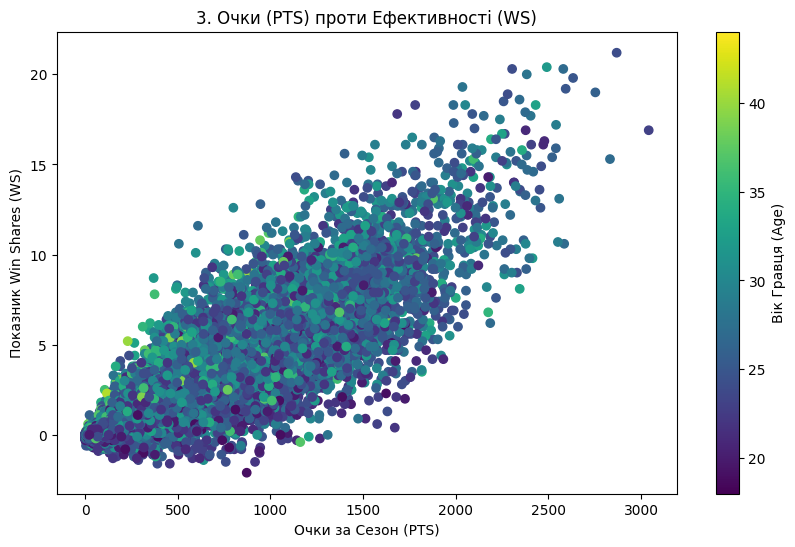

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['PTS'], df_clean['WS'], c=df_clean['Age'], cmap='viridis')
plt.colorbar(label='Вік Гравця (Age)')
plt.title('3. Очки (PTS) проти Ефективності (WS)')
plt.xlabel('Очки за Сезон (PTS)')
plt.ylabel('Показник Win Shares (WS)')


Text(0, 0.5, 'Очки набрані за сезон (PTS)')

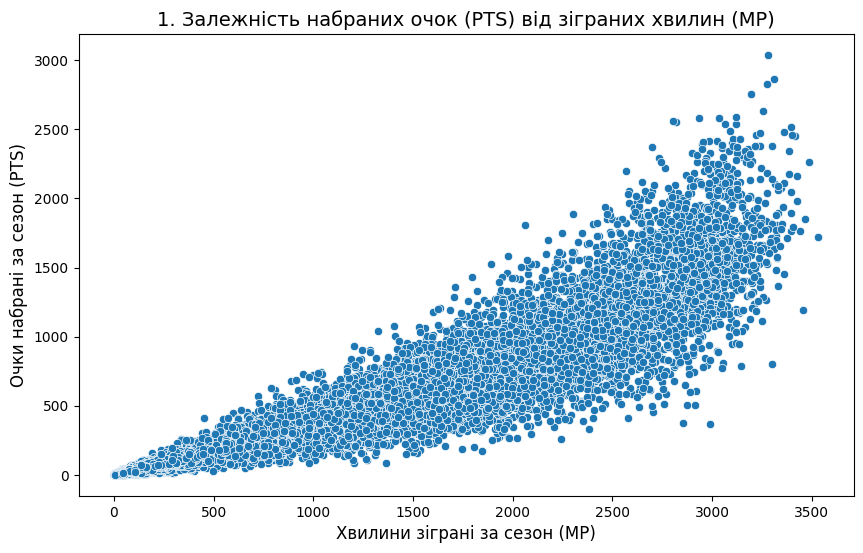

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MP',y='PTS', data=df_clean)
plt.title('1. Залежність набраних очок (PTS) від зіграних хвилин (MP)', fontsize=14)
plt.xlabel('Хвилини зіграні за сезон (MP)', fontsize=12)
plt.ylabel('Очки набрані за сезон (PTS)', fontsize=12)

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'PTS'),
  Text(0, 2.5, 'AST'),
  Text(0, 3.5, 'Year'),
  Text(0, 4.5, 'MP'),
  Text(0, 5.5, 'WS'),
  Text(0, 6.5, '3PA')])

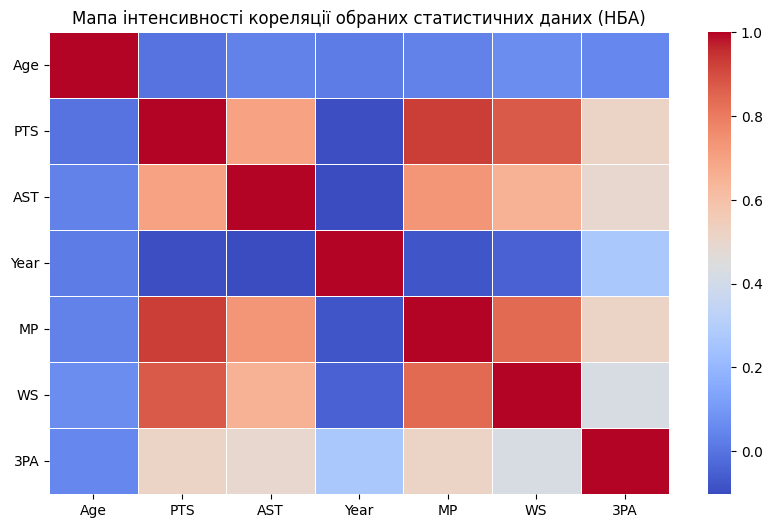

In [10]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
df_heatmap = df_clean[numeric_cols]
correlation_matrix = df_heatmap.corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix,annot=False, cmap='coolwarm',linewidths=.5)
plt.title('Мапа інтенсивності кореляції обраних статистичних даних (НБА)')
plt.yticks(rotation=0)



Text(0, 0.5, 'Очки за Сезон (PTS)')

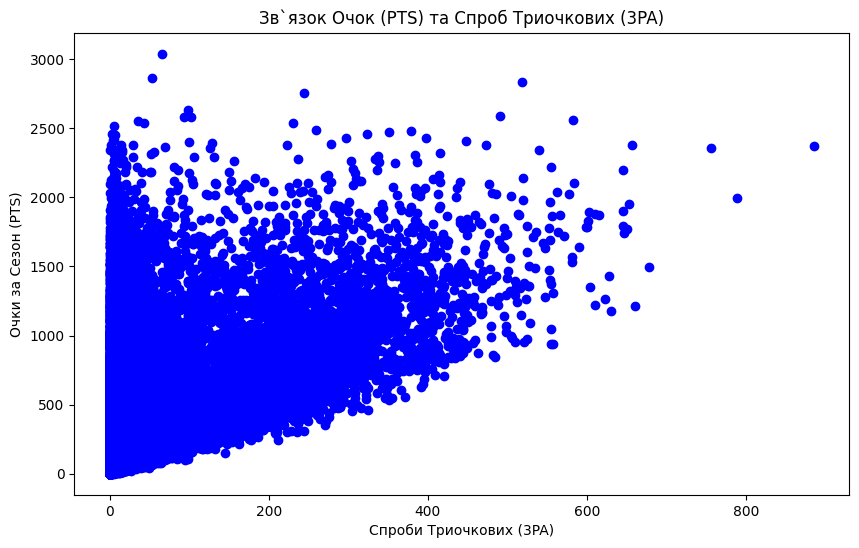

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['3PA'], df_clean['PTS'], color='blue')
plt.title('Зв`язок Очок (PTS) та Спроб Триочкових (3PA)')
plt.xlabel('Спроби Триочкових (3PA)')
plt.ylabel('Очки за Сезон (PTS)')


In [12]:
fig1 = px.scatter_3d(
    df_multivariate, 
    x='Age', 
    y='PTS', 
    z='AST', 
    color='Simple_pos', 
    symbol='Simple_pos', 
    opacity=0.7,
    title='3D Розсіювання: Очки та Передачі за Віком та Позицією',
    labels={'Age': 'Вік', 'PTS': 'Очки (Points)', 'AST': 'Передачі (Assists)'}
)
fig1.show()

In [17]:
pt_data_aggregated = df_multivariate.groupby(['Age', 'MP']).agg(
    Avg_PTS=('PTS', 'mean')
).reset_index()
bins = np.arange(0, pt_data_aggregated['MP'].max() + 5, 5)
pt_data_aggregated['MP_Binned'] = pd.cut(pt_data_aggregated['MP'], bins=bins, include_lowest=True)
pt_data_aggregated['MP_Mid'] = pt_data_aggregated['MP_Binned'].apply(lambda x: x.mid).astype(float)
pt_surface = pt_data_aggregated.groupby(['Age', 'MP_Mid'])['Avg_PTS'].mean().unstack(fill_value=0)

X = pt_surface.index.values      
Y = pt_surface.columns.values      
Z = pt_surface.values             
fig = go.Figure(data=go.Surface(
    z=Z, 
    x=X, 
    y=Y,
    colorscale='Plasma', 
    showscale=True 
))
name = 'Середні PTS як Функція Віку та Хвилин (MP)'

camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=1.8, y=1.8, z=0.5) 
)

fig.update_layout(
    title=name,
    width=700,
    height=600,
    scene_camera=camera,
    margin=dict(t=50, r=0, l=20, b=20),
    scene=dict(
        xaxis_title='Вік (Age)',
        yaxis_title='Хвилини (MP) (інтервали)',
        zaxis_title='Середні Очки (Avg PTS)'
    )
)

fig.show()

In [19]:
df_trajectory = df_multivariate.groupby(['Year', 'Simple_pos']).agg(
    Avg_PTS=('PTS', 'mean'),
    Avg_WS=('WS', 'mean')
).reset_index()
fig3d = px.line_3d(
    df_trajectory, 
    x="Avg_PTS",      # X: Середні очки
    y="Avg_WS",       # Y: Середня ефективність (Win Shares)
    z="Year",         # Z: Час (Рік) - вісь, що показує траєкторію
    color='Simple_pos', # Кожна позиція (G, F, C) отримує окрему кольорову лінію
    title='3D Траєкторія: Зміна Середніх PTS та WS з Роками за Позиціями',
    labels={'Avg_PTS': 'Середні Очки', 'Avg_WS': 'Середні Win Shares', 'Year': 'Рік'}
)
fig3d.show()